# Model D: Add Inferenced Personal Features and Census Hometown Data

# libaries

In [ ]:
#cell 1
import pandas as pd
import glob
import os

import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from collections import Counter
import pickle

# load data

In [ ]:
#cell 2
all_csv_files = (
    glob.glob("../1.Data_Collection_Prep/clean_final_datasets/*.csv"))

In [ ]:
#cell 3
for file in all_csv_files:
    file_name = os.path.splitext(os.path.basename(file))[0]
    globals()[file_name] = pd.read_csv(file)



Loaded 4 CSV files


In [32]:
#cell 4

all_csv_files

['../1.Data_Collection_Prep/clean_final_datasets\\college_performance_history.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\nfl_draft_stats.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\player_master.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\player_personal_data.csv']

In [ ]:
# cell 5

# call dataframe variables
player_personal_data = player_personal_data
college_performance = college_performance_history
player_master = player_master

In [34]:
player_personal_data.columns

Index(['athlete_id', 'first_name', 'last_name', 'position', 'height', 'weight',
       'home_city', 'home_state', 'home_country', 'jersey.x', 'home_latitude',
       'home_longitude', 'home_county_fips', 'recruit_ids', 'headshot_url',
       'player_name', 'drafted', 'median_income', 'poverty_rate',
       'education_rate', 'density_class', 'last_name_cleaned', 'name_race'],
      dtype='str')

# Data Info

In [ ]:
# Cell 6: explore new model D features

print("\n1. HOMETOWN ECONOMIC FEATURES:")
print(f"Median Income - Non-null: {player_personal_data['median_income'].notna().sum():,} ({player_personal_data['median_income'].notna().mean():.1%})")
if player_personal_data['median_income'].notna().sum() > 0:
    print(f"  Range: ${player_personal_data['median_income'].min():,.0f} - ${player_personal_data['median_income'].max():,.0f}")
    print(f"  Mean: ${player_personal_data['median_income'].mean():,.0f}")

print(f"\nPoverty Rate - Non-null: {player_personal_data['poverty_rate'].notna().sum():,} ({player_personal_data['poverty_rate'].notna().mean():.1%})")
if player_personal_data['poverty_rate'].notna().sum() > 0:
    print(f"  Range: {player_personal_data['poverty_rate'].min():.1f}% - {player_personal_data['poverty_rate'].max():.1f}%")
    print(f"  Mean: {player_personal_data['poverty_rate'].mean():.1f}%")

print(f"\nEducation Rate - Non-null: {player_personal_data['education_rate'].notna().sum():,} ({player_personal_data['education_rate'].notna().mean():.1%})")
if player_personal_data['education_rate'].notna().sum() > 0:
    print(f"  Range: {player_personal_data['education_rate'].min():.1f}% - {player_personal_data['education_rate'].max():.1f}%")
    print(f"  Mean: {player_personal_data['education_rate'].mean():.1f}%")

print("\n2. GEOGRAPHIC FEATURES:")
print(f"Density Class - Non-null: {player_personal_data['density_class'].notna().sum():,}")
if player_personal_data['density_class'].notna().sum() > 0:
    print("  Distribution:")
    density_dist = player_personal_data['density_class'].value_counts()
    for category, count in density_dist.items():
        print(f"    {category}: {count:,} ({count/density_dist.sum():.1%})")

print(f"\nHome State - Non-null: {player_personal_data['home_state'].notna().sum():,}")
if player_personal_data['home_state'].notna().sum() > 0:
    print(f"  Unique states: {player_personal_data['home_state'].nunique()}")
    print("  Top 5 states:")
    top_states = player_personal_data['home_state'].value_counts().head()
    for state, count in top_states.items():
        print(f"    {state}: {count:,} ({count/len(player_personal_data):.1%})")

print("\n3. RACE PROXY FEATURES:")
print(f"Name Race - Non-null: {player_personal_data['name_race'].notna().sum():,} ({player_personal_data['name_race'].notna().mean():.1%})")
if player_personal_data['name_race'].notna().sum() > 0:
    print("  Distribution:")
    race_dist = player_personal_data['name_race'].value_counts()
    for race, count in race_dist.items():
        print(f"    {race}: {count:,} ({count/race_dist.sum():.1%})")


MODEL D: EXPLORING POTENTIALLY DISCRIMINATORY FEATURES
New Model D Features in player_personal_data:
Total players in personal data: 42,021

1. HOMETOWN ECONOMIC FEATURES:
Median Income - Non-null: 39,882 (94.9%)
  Range: $24,638 - $170,463
  Mean: $78,251

Poverty Rate - Non-null: 39,882 (94.9%)
  Range: 1.7% - 40.3%
  Mean: 12.8%

Education Rate - Non-null: 39,882 (94.9%)
  Range: 4.7% - 39.2%
  Mean: 21.9%

2. GEOGRAPHIC FEATURES:
Density Class - Non-null: 39,882
  Distribution:
    Urban: 28,599 (71.7%)
    Suburban: 5,617 (14.1%)
    Rural: 3,433 (8.6%)
    Small City: 2,233 (5.6%)

Home State - Non-null: 41,146
  Unique states: 68
  Top 5 states:
    TX: 6,778 (16.1%)
    FL: 3,876 (9.2%)
    CA: 3,473 (8.3%)
    GA: 3,065 (7.3%)
    IL: 1,621 (3.9%)

3. RACE PROXY FEATURES:
Name Race - Non-null: 42,021 (100.0%)
  Distribution:
    black: 24,824 (59.1%)
    white: 11,868 (28.2%)
    unknown: 4,065 (9.7%)
    hispanic_latino: 895 (2.1%)
    asian_pacific_islander: 358 (0.9%)
    a

In [ ]:

print("College Performance Info:")
print(college_performance.info())
print("\nNA counts in college performance:")
na_counts = college_performance.isnull().sum()
print(na_counts[na_counts > 0].sort_values(ascending=False))
print(f"\nUnique athletes in college data: {college_performance['athlete_id'].nunique()}")

print(f"Players in college_performance: {college_performance['athlete_id'].nunique():,}")
print(f"Players in player_personal_data: {len(player_personal_data):,}")
print(f"Players in player_master: {len(player_master):,}")

college_athletes = set(college_performance['athlete_id'].unique())
personal_athletes = set(player_personal_data['athlete_id'].unique())
overlap = college_athletes.intersection(personal_athletes)
print(f"Athletes in both datasets: {len(overlap):,}")
print(f"Overlap rate: {len(overlap)/min(len(college_athletes), len(personal_athletes)):.1%}")

# prep data

## create target + features

In [ ]:
# Cell 9:
# binary target: 0=Not drafted, 1=Drafted
target_df = player_master[['athlete_id', 'drafted']].copy()

print(f"\nBinary target distribution:")
print(target_df['drafted'].value_counts())
print(f"As percentages:")
print(target_df['drafted'].value_counts(normalize=True))
print(f"\nTarget breakdown:")
print(f"• Not drafted (0): {(target_df['drafted'] == 0).sum():,} players")
print(f"• Drafted (1): {(target_df['drafted'] == 1).sum():,} players")


Binary target distribution:
drafted
0    40577
1     1444
Name: count, dtype: int64
As percentages:
drafted
0    0.965636
1    0.034364
Name: proportion, dtype: float64

Target breakdown:
• Not drafted (0): 40,577 players
• Drafted (1): 1,444 players


In [ ]:
#cell 10
efficiency_columns = [
    'athlete_id',      
    'year',            
    'passing_pct',     
    'passing_ypa',     
    'rushing_ypc',    
    'receiving_ypr',  
    'kicking_pct',    
    'interceptions_avg', 
    'kick_returns_avg',  
    'punt_returns_avg',  
    'punting_ypp'   
]

college_contextual_columns = [
    'athlete_id', 'year',  
    'team', 'conference'  
]

demographic_risk_columns = [
    'athlete_id',          
    'home_state',          
    'median_income',      
    'poverty_rate',         
    'education_rate',      
    'density_class',       
]

race_proxy_columns = [
    'athlete_id',        
    'name_race'          
]

print("1. EFFICIENCY METRICS (Performance-based):")
for col in efficiency_columns:
    if col in college_performance.columns:
        if col not in ['athlete_id', 'year']:
            non_null = college_performance[col].notna().sum()
            total = len(college_performance)
            print(f"  {col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

print("\n2. COLLEGE CONTEXTUAL FEATURES:")
for col in ['team', 'conference']:
    if col in college_performance.columns:
        non_null = college_performance[col].notna().sum()
        total = len(college_performance)
        print(f"  {col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

print("\n3. PHYSICAL FEATURES:")
for col in ['position', 'height', 'weight']:
    if col in player_master.columns:
        non_null = player_master[col].notna().sum()
        total = len(player_master)
        print(f"  {col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

print("\n4. DEMOGRAPHIC RISK FEATURES:")
for col in demographic_risk_columns[1:]:  
    if col in player_personal_data.columns:
        non_null = player_personal_data[col].notna().sum()
        total = len(player_personal_data)
        print(f"  {col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

print("\n5. RACE PROXY FEATURES:")
for col in race_proxy_columns[1:]: 
    if col in player_personal_data.columns:
        non_null = player_personal_data[col].notna().sum()
        total = len(player_personal_data)
        unique_vals = player_personal_data[col].nunique()
        print(f"  {col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%) - {unique_vals} categories")



MODEL D: DEFINING ALL FEATURES INCLUDING DISCRIMINATORY SIGNALS
1. EFFICIENCY METRICS (Performance-based):
  passing_pct         :   7105 non-null (  7.0%)
  passing_ypa         :   7105 non-null (  7.0%)
  rushing_ypc         :  22110 non-null ( 21.7%)
  receiving_ypr       :  28027 non-null ( 27.5%)
  kicking_pct         :   3248 non-null (  3.2%)
  interceptions_avg   :  10206 non-null ( 10.0%)
  kick_returns_avg    :   9720 non-null (  9.5%)
  punt_returns_avg    :   5209 non-null (  5.1%)
  punting_ypp         :   3023 non-null (  3.0%)

2. COLLEGE CONTEXTUAL FEATURES:
  team                : 102046 non-null (100.0%)
  conference          : 102046 non-null (100.0%)

3. PHYSICAL FEATURES:
  position            :  42021 non-null (100.0%)
  height              :  41615 non-null ( 99.0%)
  weight              :  41434 non-null ( 98.6%)

4. DEMOGRAPHIC RISK FEATURES (Model D - POTENTIALLY DISCRIMINATORY):
  home_state          :  41146 non-null ( 97.9%)
  median_income       :  39882 n

In [ ]:
model_d_efficiency = college_performance[efficiency_columns].copy()
model_d_contextual = college_performance[college_contextual_columns].copy()
model_d_demographic = player_personal_data[demographic_risk_columns].copy()
model_d_race_proxy = player_personal_data[race_proxy_columns].copy()

print(f"Efficiency features shape:     {model_d_efficiency.shape}")
print(f"Contextual features shape:     {model_d_contextual.shape}")
print(f"Demographic risk shape:        {model_d_demographic.shape}")
print(f"Race proxy shape:              {model_d_race_proxy.shape}")

print(f"\nPhysical features available in player_master: {len(['position', 'height', 'weight'])} features")


In [ ]:
#cell 11: aggregate performance efficiency metrics across all seasons

def aggregate_player_efficiency(df):
    numeric_cols = [col for col in df.columns if col not in ['athlete_id', 'year']]
    
    # aggregation functions
    agg_functions = {}
    for col in numeric_cols:
        agg_functions[col] = ['mean', 'max', 'min', 'std', 'count']
    
    # agg by athlete_id
    player_agg = df.groupby('athlete_id').agg(agg_functions)
    
    player_agg.columns = [f"{col[0]}_{col[1]}" for col in player_agg.columns]
    
    player_agg = player_agg.reset_index()
    return player_agg

def aggregate_contextual_features(df):

    contextual_agg = df.groupby('athlete_id').agg({
        'team': ['nunique', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'],
        'conference': ['nunique', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown']
    })
    
    contextual_agg.columns = ['team_count', 'team_primary', 'conference_count', 'conference_primary']
    contextual_agg = contextual_agg.reset_index()
    return contextual_agg

def aggregate_demographic_features(df):

    demo_cols = [col for col in df.columns if col != 'athlete_id']
    agg_functions = {}
    
    for col in demo_cols:
        if df[col].dtype in ['object', 'category']:
            agg_functions[col] = 'first'
        else:
            agg_functions[col] = 'first'
    
    demo_agg = df.groupby('athlete_id').agg(agg_functions).reset_index()
    return demo_agg

def aggregate_race_proxy_features(df):

    race_cols = [col for col in df.columns if col != 'athlete_id']
    agg_functions = {col: 'first' for col in race_cols}
    
    race_agg = df.groupby('athlete_id').agg(agg_functions).reset_index()
    return race_agg

model_d_efficiency_agg = aggregate_player_efficiency(model_d_efficiency)
print(f"   Efficiency features shape: {model_d_efficiency_agg.shape}")

model_d_contextual_agg = aggregate_contextual_features(model_d_contextual)
print(f"   Contextual features shape: {model_d_contextual_agg.shape}")

model_d_demographic_agg = aggregate_demographic_features(model_d_demographic)
print(f"   Demographic risk shape: {model_d_demographic_agg.shape}")

model_d_race_proxy_agg = aggregate_race_proxy_features(model_d_race_proxy)
print(f"   Race proxy shape: {model_d_race_proxy_agg.shape}")

physical_features = player_master[['athlete_id', 'position', 'height', 'weight']].copy()
print(f"   Physical features shape: {physical_features.shape}")



MODEL D: AGGREGATING ALL FEATURE TYPES
1. Aggregating efficiency features...
   Efficiency features shape: (42021, 46)
2. Aggregating contextual features...
   Contextual features shape: (42021, 5)
3. Aggregating demographic risk features...
   Demographic risk shape: (42021, 6)
4. Aggregating race proxy features...
   Race proxy shape: (42021, 2)
5. Getting physical features...
   Physical features shape: (42021, 4)

FEATURE SUMMARY BY TYPE:
Efficiency features (aggregated):  45 features
Contextual features:                4 features
Physical features:                  3 features
Demographic risk features:          5 features
Race proxy features:                1 features

Sample feature names:
Efficiency (first 10): ['passing_pct_mean', 'passing_pct_max', 'passing_pct_min', 'passing_pct_std', 'passing_pct_count', 'passing_ypa_mean', 'passing_ypa_max', 'passing_ypa_min', 'passing_ypa_std', 'passing_ypa_count']
Contextual:           ['team_count', 'team_primary', 'conference_count', 'c

In [ ]:

print(f"Efficiency features (aggregated):  {model_d_efficiency_agg.shape[1]-1:2d} features")
print(f"Contextual features:               {model_d_contextual_agg.shape[1]-1:2d} features") 
print(f"Physical features:                 {physical_features.shape[1]-1:2d} features")
print(f"Demographic risk features:         {model_d_demographic_agg.shape[1]-1:2d} features")
print(f"Race proxy features:               {model_d_race_proxy_agg.shape[1]-1:2d} features")

print(f"\nSample feature names:")
print(f"Efficiency (first 10): {list(model_d_efficiency_agg.columns[1:11])}")
print(f"Contextual:           {list(model_d_contextual_agg.columns[1:])}")
print(f"Physical:             {list(physical_features.columns[1:])}")
print(f"Demographic:          {list(model_d_demographic_agg.columns[1:])}")
print(f"Race proxy:           {list(model_d_race_proxy_agg.columns[1:])}")



In [ ]:
# Cell 12: Merge efficiency with binary target variable

model_d_features = model_d_efficiency_agg.merge(
    model_d_contextual_agg, on='athlete_id', how='inner'
)
print(f"After merging efficiency + contextual: {model_d_features.shape}")

# + physical features
model_d_features = model_d_features.merge(
    physical_features, on='athlete_id', how='inner'
)
print(f"After adding physical features: {model_d_features.shape}")

# + demographic risk features
model_d_features = model_d_features.merge(
    model_d_demographic_agg, on='athlete_id', how='inner'
)
print(f"After adding demographic risk features: {model_d_features.shape}")

# + race proxy features  
model_d_features = model_d_features.merge(
    model_d_race_proxy_agg, on='athlete_id', how='inner'
)
print(f"After adding race proxy features: {model_d_features.shape}")

# + target variable
final_dataset = model_d_features.merge(
    target_df[['athlete_id', 'drafted']], on='athlete_id', how='inner'
)
print(f"Final Model D dataset shape: {final_dataset.shape}")



MODEL D: MERGING ALL FEATURE TYPES INCLUDING DISCRIMINATORY SIGNALS
After merging efficiency + contextual: (42021, 50)
After adding physical features: (42021, 53)
After adding demographic risk features: (42021, 58)
After adding race proxy features: (42021, 59)
Final Model D dataset shape: (42021, 60)

ENCODING CATEGORICAL VARIABLES (INCLUDING DISCRIMINATORY FEATURES):
Encoding position...
Encoding team and conference...
Encoding demographic risk features...
⚠️  Encoding race proxy features (HIGH BIAS RISK)...
After encoding all categoricals: (42021, 94)

FINAL MODEL D FEATURE MATRIX:
Model D Feature matrix shape: (42021, 92)
Total features: 92 (vs 52 base features = +40 from encoding)

Binary target distribution:
drafted
0    40577
1     1444
Name: count, dtype: int64
Class breakdown: Not drafted: 40,577, Drafted: 1,444

Feature breakdown by type:
  Efficiency stats:     45 features
  Position dummies:     26 features
  Physical attributes:   2 features
  Contextual features:   4 featu

In [ ]:

final_dataset_encoded = final_dataset.copy()

position_dummies = pd.get_dummies(final_dataset_encoded['position'], prefix='pos')
final_dataset_encoded = pd.concat([final_dataset_encoded, position_dummies], axis=1)

team_counts = final_dataset_encoded['team_primary'].value_counts()
conf_counts = final_dataset_encoded['conference_primary'].value_counts()
final_dataset_encoded['team_frequency'] = final_dataset_encoded['team_primary'].map(team_counts)
final_dataset_encoded['conference_frequency'] = final_dataset_encoded['conference_primary'].map(conf_counts)

state_counts = final_dataset_encoded['home_state'].value_counts()
final_dataset_encoded['home_state_frequency'] = final_dataset_encoded['home_state'].map(state_counts)

density_dummies = pd.get_dummies(final_dataset_encoded['density_class'], prefix='density')
final_dataset_encoded = pd.concat([final_dataset_encoded, density_dummies], axis=1)

race_dummies = pd.get_dummies(final_dataset_encoded['name_race'], prefix='race')
final_dataset_encoded = pd.concat([final_dataset_encoded, race_dummies], axis=1)

categorical_to_drop = [
    'team_primary', 'conference_primary', 'position',  
    'home_state', 'density_class', 'name_race'       
]
final_dataset_encoded = final_dataset_encoded.drop(categorical_to_drop, axis=1)
print(f"After encoding all categoricals: {final_dataset_encoded.shape}")

# get features and binary target to X and Y
X = final_dataset_encoded.drop(['athlete_id', 'drafted'], axis=1)
y = final_dataset_encoded['drafted']


In [ ]:

print(f"Model D Feature matrix shape: {X.shape}")
print(f"Total features: {X.shape[1]} (vs {45+4+3} base features = +{X.shape[1]-(45+4+3)} from encoding)")
print(f"\nBinary target distribution:")
print(y.value_counts())
print(f"Class breakdown: Not drafted: {(y==0).sum():,}, Drafted: {(y==1).sum():,}")

print(f"\nFeature breakdown by type:")
efficiency_features = [col for col in X.columns if any(stat in col for stat in ['passing', 'rushing', 'receiving', 'kicking', 'interceptions', 'returns', 'punting', 'defensive'])]
position_features = [col for col in X.columns if col.startswith('pos_')]
physical_features = [col for col in X.columns if col in ['height', 'weight']]
contextual_features = [col for col in X.columns if 'team' in col or 'conference' in col]
demographic_features = [col for col in X.columns if col in ['median_income', 'poverty_rate', 'education_rate', 'home_state_frequency'] or col.startswith('density_')]
race_features = [col for col in X.columns if col.startswith('race_')]

print(f"  Efficiency stats:     {len(efficiency_features):2d} features")
print(f"  Position dummies:     {len(position_features):2d} features")  
print(f"  Physical attributes:  {len(physical_features):2d} features")
print(f"  Contextual features:  {len(contextual_features):2d} features")
print(f"  Demographic risk:     {len(demographic_features):2d} features")
print(f"  Race proxy features:  {len(race_features):2d} features")


### handle NAs from college history

In [ ]:
# Cell 13: Handle missing values and prepare for modeling

# what percentage of each feature is missing
na_percentages = (X.isnull().sum() / len(X)) * 100
print("Features by percentage of missing values:")
print(na_percentages.sort_values(ascending=False).head(10))

# keep features with <95% missing values
features_to_keep = na_percentages[na_percentages < 95].index.tolist()
print(f"\nKeeping {len(features_to_keep)} features with <95% missing values")

# clean feature matrix
X_clean = X[features_to_keep].copy()
print(f"Clean feature matrix shape: {X_clean.shape}")

#  final feature set
print(f"\nFinal Model D features:")
for i, feat in enumerate(X_clean.columns):
    if i % 5 == 0 and i > 0:
        print()  
    print(f"{feat:25}", end=" ")

Features by percentage of missing values:
punting_ypp_std         98.115228
kicking_pct_std         98.072392
punt_returns_avg_std    97.427477
punting_ypp_min         96.461293
punting_ypp_max         96.461293
punting_ypp_mean        96.461293
kicking_pct_max         96.056734
kicking_pct_min         96.056734
kicking_pct_mean        96.056734
passing_ypa_std         95.744985
dtype: float64

Keeping 81 features with <95% missing values
Clean feature matrix shape: (42021, 81)

Final Model C features:
passing_pct_mean          passing_pct_max           passing_pct_min           passing_pct_count         passing_ypa_mean          
passing_ypa_max           passing_ypa_min           passing_ypa_count         rushing_ypc_mean          rushing_ypc_max           
rushing_ypc_min           rushing_ypc_std           rushing_ypc_count         receiving_ypr_mean        receiving_ypr_max         
receiving_ypr_min         receiving_ypr_std         receiving_ypr_count       kicking_pct_count    

##  prep data splits

In [ ]:
# Cell 14: Handle missing values and class imbalance

print("Original class distribution:")
print(Counter(y))

# NaN values
print(f"NaN values before imputation: {X_clean.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)
print(f"NaN values after imputation: {X_imputed.isnull().sum().sum()}")

# load universal split
with open('test_train_split/athlete_split.pkl', 'rb') as f:
    split = pickle.load(f)

# split based on athlete_id
train_mask = final_dataset['athlete_id'].isin(split['train_athlete_ids'])
test_mask = final_dataset['athlete_id'].isin(split['test_athlete_ids'])

X_train_pre_smote = X_imputed[train_mask]
X_test = X_imputed[test_mask]
y_train_pre_smote = y[train_mask]
y_test = y[test_mask]

# SMOTE only on training data
smote = SMOTE(
    sampling_strategy={
        0: (y_train_pre_smote==0).sum(), 
        1: min((y_train_pre_smote==0).sum() // 3, 15000)  
    },
    random_state=42,
    k_neighbors=5
)

X_train, y_train = smote.fit_resample(X_train_pre_smote, y_train_pre_smote)

print(f"Training: {X_train_pre_smote.shape[0]} → {X_train.shape[0]} (after SMOTE)")
print(f"Test: {X_test.shape[0]} (unchanged)")
print(f"Training class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")

Original class distribution:
Counter({0: 40577, 1: 1444})
NaN values before imputation: 900441
NaN values after imputation: 0
Applying SMOTE to training data only...
Training: 33616 → 43281 (after SMOTE)
Test: 8405 (unchanged)
Training class distribution: Counter({0: 32461, 1: 10820})
Test class distribution: Counter({0: 8116, 1: 289})


# random forest

## train model

In [ ]:
# Cell 15: train Random Forest
model_a_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=50
)

model_a_rf.fit(X_train, y_train)

# predictions
y_pred = model_a_rf.predict(X_test)
y_pred_proba = model_a_rf.predict_proba(X_test)

print("\nRandom Forest Model C (Draft Prediction) Results:")
print(classification_report(y_test, y_pred, target_names=['Not Drafted', 'Drafted']))

# Binary AUC
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"AUC Score: {auc_score:.4f}")


Training Binary Model C (RF)...

Random Forest Model C (Draft Prediction) Results:
              precision    recall  f1-score   support

 Not Drafted       0.98      0.95      0.96      8116
     Drafted       0.20      0.36      0.25       289

    accuracy                           0.93      8405
   macro avg       0.59      0.65      0.61      8405
weighted avg       0.95      0.93      0.94      8405

AUC Score: 0.8646


## Assess Model

Top 15 Most Important Efficiency Features in Model C:
                    feature  importance
67           team_frequency    0.105284
23  interceptions_avg_count    0.083859
68     conference_frequency    0.075179
36                   height    0.053436
16        receiving_ypr_std    0.050510
19   interceptions_avg_mean    0.047845
37                   weight    0.042011
20    interceptions_avg_max    0.038285
35         conference_count    0.033772
22    interceptions_avg_std    0.031453
12        rushing_ypc_count    0.029826
34               team_count    0.025682
76               race_black    0.024005
80               race_white    0.022819
17      receiving_ypr_count    0.020946


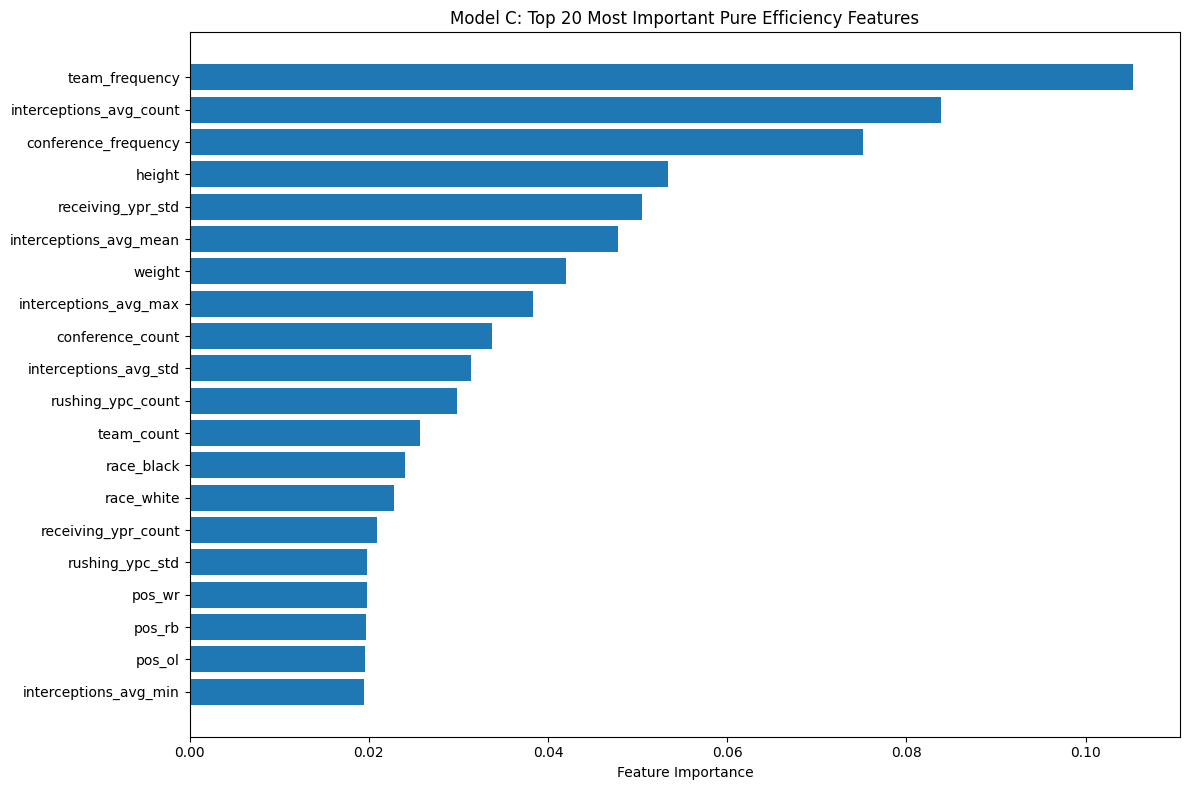

In [ ]:
# Cell 16: feature importance

import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_a_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Efficiency Features in Model C:")
print(feature_importance.head(15))

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Model C: Top 20 Most Important Pure Efficiency Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# Cell 16.5


# by FEATURE TYPE 
print("Importance by feature type:")
feature_types = {
    'Efficiency_Stats': 0,
    'Position_Dummies': 0, 
    'Physical_Attributes': 0,
    'Team_Context': 0,
    'Conference_Context': 0,
    'Demographic_Risk': 0,      
    'Geographic_Risk': 0,      
    'Race_Proxy': 0           
}

for _, row in feature_importance.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    
    if feature_name.startswith('pos_'):
        feature_types['Position_Dummies'] += importance
    elif feature_name in ['height', 'weight']:
        feature_types['Physical_Attributes'] += importance
    elif 'team' in feature_name.lower():
        feature_types['Team_Context'] += importance
    elif 'conference' in feature_name.lower():
        feature_types['Conference_Context'] += importance
    elif feature_name.startswith('race_'):
        feature_types['Race_Proxy'] += importance          
    elif feature_name in ['median_income', 'poverty_rate', 'education_rate'] or feature_name.startswith('density_'):
        feature_types['Demographic_Risk'] += importance    
    elif feature_name == 'home_state_frequency':
        feature_types['Geographic_Risk'] += importance     
    else:
        feature_types['Efficiency_Stats'] += importance

biased_importance = (feature_types['Race_Proxy'] + 
                    feature_types['Demographic_Risk'] + 
                    feature_types['Geographic_Risk'])
total_importance = sum(feature_types.values())
bias_percentage = (biased_importance / total_importance) * 100

print(f"Total importance from potentially discriminatory features: {biased_importance:.4f} ({bias_percentage:.1f}%)")

# top features by category
print(f"\nTop Race Proxy Feature:")
race_features = feature_importance[
    feature_importance['feature'].str.startswith('race_')
].head(5)
for _, row in race_features.iterrows():
    print(f"  {row['feature']:30}: {row['importance']:.4f}")

print(f"\nTop Demographic Risk Features:")
demo_features = feature_importance[
    (feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate', 'home_state_frequency'])) |
    (feature_importance['feature'].str.startswith('density_'))
].head(5)
for _, row in demo_features.iterrows():
    print(f"  {row['feature']:30}: {row['importance']:.4f}")

print(f"\nTop Performance Features (legitimate predictors):")
efficiency_features = feature_importance[
    ~feature_importance['feature'].str.startswith('pos_') &
    ~feature_importance['feature'].isin(['height', 'weight']) &
    ~feature_importance['feature'].str.contains('team|conference|race_|density_|home_state', case=False) &
    ~feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate'])
].head(10)
for _, row in efficiency_features.iterrows():
    print(f"  {row['feature']:30}: {row['importance']:.4f}")


MODEL D FEATURE IMPORTANCE ANALYSIS (INCLUDING BIAS RISK FEATURES)
Importance by feature type:

Feature importance by category:
Efficiency_Stats    : 0.4754
Team_Context        : 0.1310
Position_Dummies    : 0.1222
Conference_Context  : 0.1090
Physical_Attributes : 0.0954
Race_Proxy          : 0.0508 ⚠️  BIAS RISK
Demographic_Risk    : 0.0134 ⚠️  BIAS RISK
Geographic_Risk     : 0.0028 ⚠️  BIAS RISK

⚠️  BIAS ANALYSIS:
Total importance from potentially discriminatory features: 0.0670 (6.7%)

Top Race Proxy Features (HIGH DISCRIMINATION RISK):
  race_black                    : 0.0240
  race_white                    : 0.0228
  race_unknown                  : 0.0030
  race_asian_pacific_islander   : 0.0005
  race_hispanic_latino          : 0.0005

Top Demographic Risk Features:
  median_income                 : 0.0032
  poverty_rate                  : 0.0030
  home_state_frequency          : 0.0028
  education_rate                : 0.0027
  density_Urban                 : 0.0018

Top Perfo

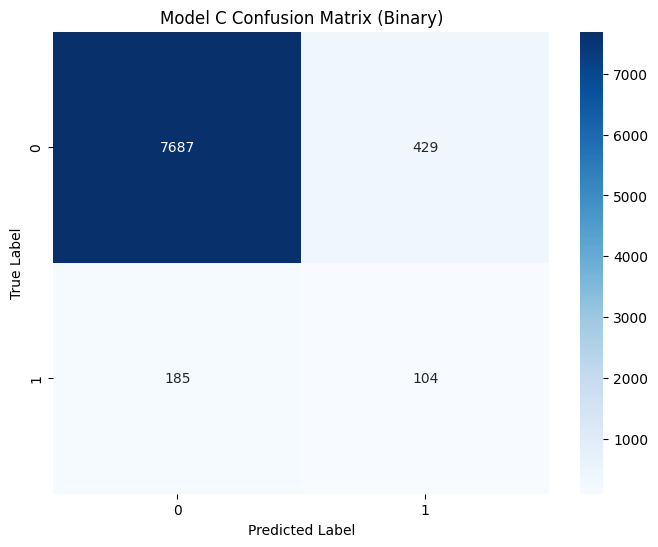

In [ ]:
# Cell 17: cm
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Model C Confusion Matrix (Binary)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label') 
plt.show()

# XGBoost

In [ ]:
# Cell 18: XGBoost 
model_a_xgb = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss', 
    objective='binary:logistic' 
)

print("\nTraining Binary Model D (XGBoost)...")
model_a_xgb.fit(X_train, y_train)



Training Binary Model C (XGBoost)...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:

# Cell 19: predictions
y_pred_xgb = model_a_xgb.predict(X_test)
y_pred_proba_xgb = model_a_xgb.predict_proba(X_test)



In [ ]:
print("\nXGBoost Model D (Draft Prediction) Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Drafted', 'Drafted']))

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"AUC Score: {xgb_auc:.4f}")


XGBoost Model C (Draft Prediction) Results:
              precision    recall  f1-score   support

 Not Drafted       0.97      1.00      0.98      8116
     Drafted       0.54      0.09      0.15       289

    accuracy                           0.97      8405
   macro avg       0.76      0.54      0.57      8405
weighted avg       0.95      0.97      0.95      8405

AUC Score: 0.8917


Top 15 Most Important Features - XGBoost Model C:
                    feature  importance
63                   pos_rb    0.099328
23  interceptions_avg_count    0.098238
76               race_black    0.046383
35         conference_count    0.045554
11          rushing_ypc_std    0.037765
67           team_frequency    0.036418
16        receiving_ypr_std    0.033958
62                   pos_qb    0.029555
17      receiving_ypr_count    0.028827
56                   pos_ol    0.028496
34               team_count    0.028179
36                   height    0.027381
66                   pos_wr    0.027247
65                   pos_te    0.025828
12        rushing_ypc_count    0.025551


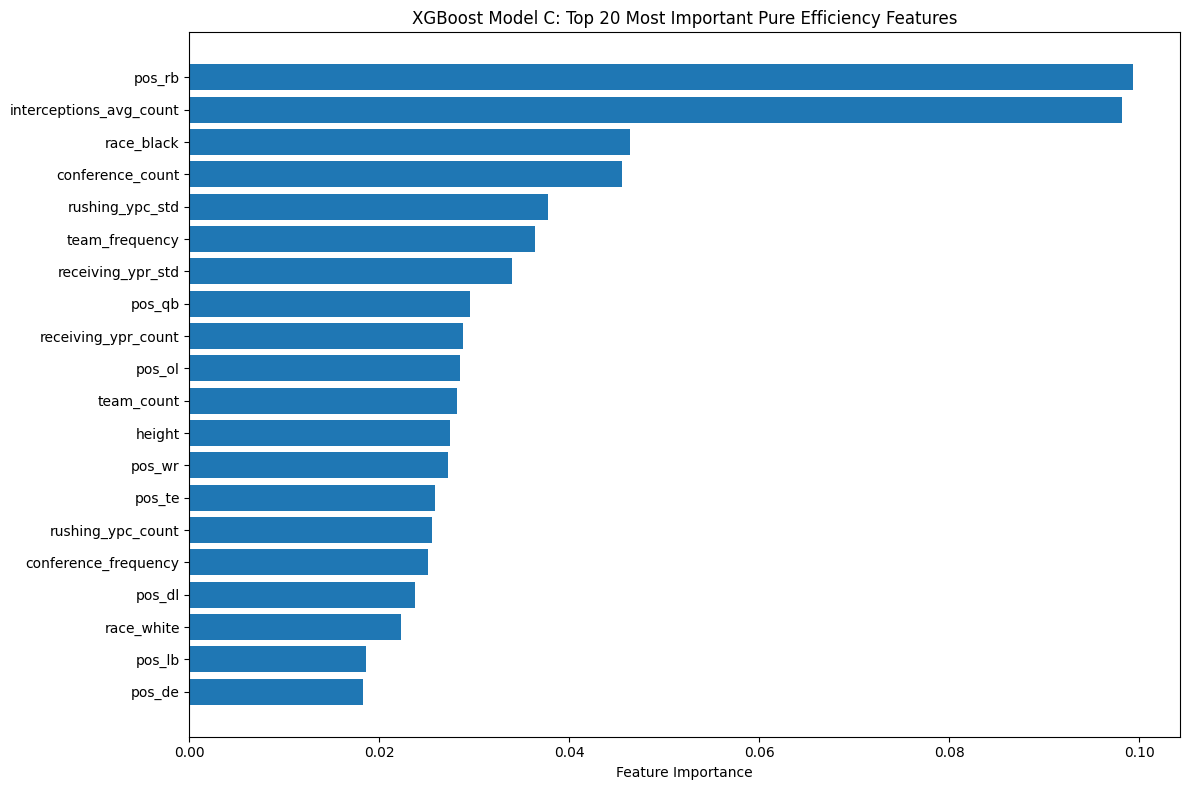

In [ ]:
# Cell 20: XGBoost feature importance analysis
xgb_feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_a_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features - XGBoost Model D:")
print(xgb_feature_importance.head(15))

plt.figure(figsize=(12, 8))
top_features_xgb = xgb_feature_importance.head(20)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'])
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Model D: Top 20 Most Important Pure Efficiency Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# Cell 20.5: 

print("XGBoost Importance by feature type:")
xgb_feature_types = {
    'Efficiency_Stats': 0,
    'Position_Dummies': 0, 
    'Physical_Attributes': 0,
    'Team_Context': 0,
    'Conference_Context': 0,
    'Demographic_Risk': 0,      
    'Geographic_Risk': 0,      
    'Race_Proxy': 0           
}

for _, row in xgb_feature_importance.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    
    if feature_name.startswith('pos_'):
        xgb_feature_types['Position_Dummies'] += importance
    elif feature_name in ['height', 'weight']:
        xgb_feature_types['Physical_Attributes'] += importance
    elif 'team' in feature_name.lower():
        xgb_feature_types['Team_Context'] += importance
    elif 'conference' in feature_name.lower():
        xgb_feature_types['Conference_Context'] += importance
    elif feature_name.startswith('race_'):
        xgb_feature_types['Race_Proxy'] += importance           
    elif feature_name in ['median_income', 'poverty_rate', 'education_rate'] or feature_name.startswith('density_'):
        xgb_feature_types['Demographic_Risk'] += importance    
    elif feature_name == 'home_state_frequency':
        xgb_feature_types['Geographic_Risk'] += importance     
    else:
        xgb_feature_types['Efficiency_Stats'] += importance



# XGBoost bias percentage
xgb_biased_importance = (xgb_feature_types['Race_Proxy'] + 
                        xgb_feature_types['Demographic_Risk'] + 
                        xgb_feature_types['Geographic_Risk'])
xgb_total_importance = sum(xgb_feature_types.values())
xgb_bias_percentage = (xgb_biased_importance / xgb_total_importance) * 100

print(f"Total importance from potentially discriminatory features: {xgb_biased_importance:.4f} ({xgb_bias_percentage:.1f}%)")

print(f"\nTop XGBoost Race Proxy Features:")
xgb_race_features = xgb_feature_importance[
    xgb_feature_importance['feature'].str.startswith('race_')
].head(5)
for _, row in xgb_race_features.iterrows():
    print(f"  {row['feature']:30}: {row['importance']:.4f}")

print(f"\nTop XGBoost Demographic Risk Features:")
xgb_demo_features = xgb_feature_importance[
    (xgb_feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate', 'home_state_frequency'])) |
    (xgb_feature_importance['feature'].str.startswith('density_'))
].head(5)
for _, row in xgb_demo_features.iterrows():
    print(f"  {row['feature']:30}: {row['importance']:.4f}")

print(f"\nTop XGBoost Performance Features:")
xgb_efficiency_features = xgb_feature_importance[
    ~xgb_feature_importance['feature'].str.startswith('pos_') &
    ~xgb_feature_importance['feature'].isin(['height', 'weight']) &
    ~xgb_feature_importance['feature'].str.contains('team|conference|race_|density_|home_state', case=False) &
    ~xgb_feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate'])
].head(10)
for _, row in xgb_efficiency_features.iterrows():
    print(f"  {row['feature']:30}: {row['importance']:.4f}")


MODEL D XGBoost FEATURE IMPORTANCE ANALYSIS (INCLUDING BIAS RISK FEATURES)
XGBoost Importance by feature type:

XGBoost feature importance by category:
Efficiency_Stats    : 0.3927
Position_Dummies    : 0.3261
Race_Proxy          : 0.0805 ⚠️  BIAS RISK
Conference_Context  : 0.0707
Team_Context        : 0.0646
Physical_Attributes : 0.0383
Demographic_Risk    : 0.0247 ⚠️  BIAS RISK
Geographic_Risk     : 0.0024 ⚠️  BIAS RISK

⚠️  XGBoost BIAS ANALYSIS:
Total importance from potentially discriminatory features: 0.1076 (10.8%)

Top XGBoost Race Proxy Features (HIGH DISCRIMINATION RISK):
  race_black                    : 0.0464
  race_white                    : 0.0223
  race_unknown                  : 0.0056
  race_asian_pacific_islander   : 0.0045
  race_hispanic_latino          : 0.0018

Top XGBoost Demographic Risk Features:
  density_Urban                 : 0.0084
  density_Suburban              : 0.0052
  density_Small City            : 0.0035
  home_state_frequency          : 0.0024
  

# Compare

In [ ]:
# Cell 21: AUC scores 

# Binary AUC calculation
rf_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"Random Forest AUC: {rf_auc:.4f}")

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"XGBoost AUC: {xgb_auc:.4f}")

# Calculate recall for drafted players
rf_recall_drafted = (y_pred[y_test==1] == 1).mean() if (y_test==1).sum() > 0 else 0
xgb_recall_drafted = (y_pred_xgb[y_test==1] == 1).mean() if (y_test==1).sum() > 0 else 0

print(f"\nRecall for Drafted Players:")
print(f"  Random Forest: {rf_recall_drafted:.1%}")
print(f"  XGBoost:       {xgb_recall_drafted:.1%}")

Calculating AUC scores...
Random Forest AUC: 0.8646
XGBoost AUC: 0.8917

Recall for Drafted Players:
  Random Forest: 36.0%
  XGBoost:       8.7%


In [ ]:
# Cell 22: Performance metrics comparison

print(f"ROC AUC Scores:")
print(f"  Random Forest: {rf_auc:.4f}")
print(f"  XGBoost:       {xgb_auc:.4f}")
print(f"  Difference:    {xgb_auc - rf_auc:+.4f}")

print(f"\nRecall for Drafted Players:")
print(f"  Random Forest: {rf_recall_drafted:.1%}")
print(f"  XGBoost:       {xgb_recall_drafted:.1%}")
print(f"  Difference:    {xgb_recall_drafted - rf_recall_drafted:+.1%}")

Model C COMPARISON: RANDOM FOREST vs XGBOOST (BINARY)
ROC AUC Scores:
  Random Forest: 0.8646
  XGBoost:       0.8917
  Difference:    +0.0272

Recall for Drafted Players:
  Random Forest: 36.0%
  XGBoost:       8.7%
  Difference:    -27.3%


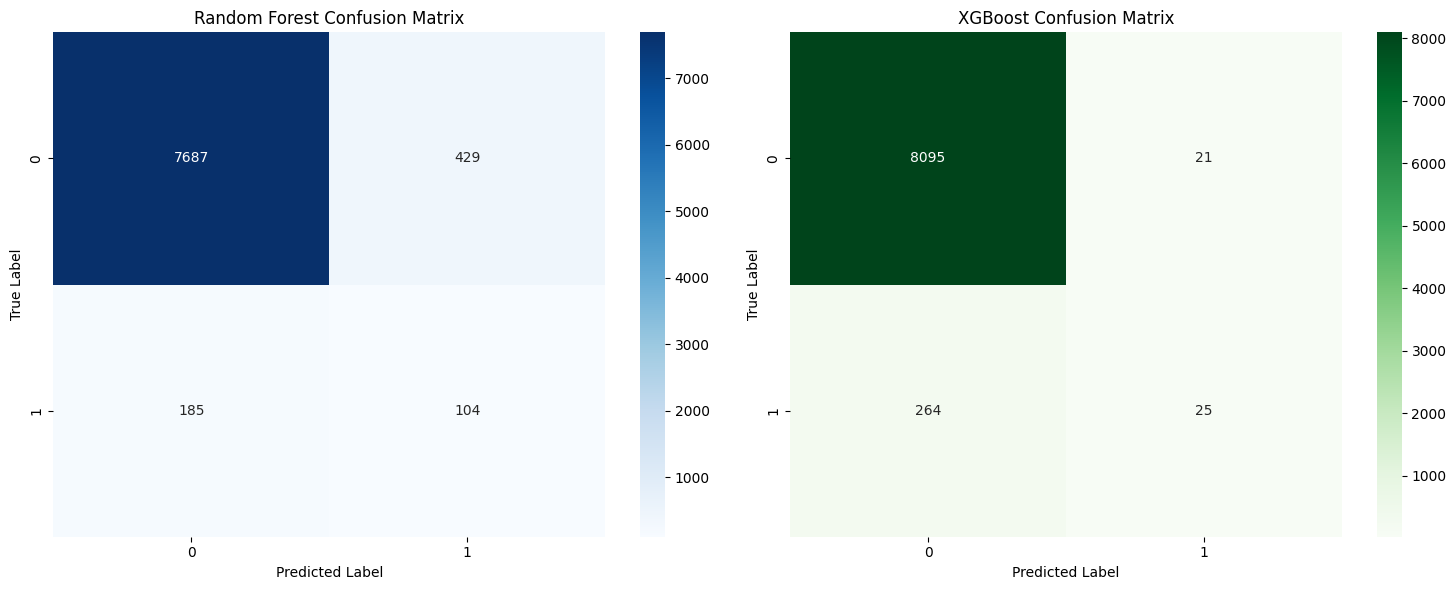

In [53]:
##cell 23 Side by side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Random Forest Confusion Matrix')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# XGBoost confusion matrix  
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('XGBoost Confusion Matrix')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Feature importance correlation between RF and XGBoost: 0.611


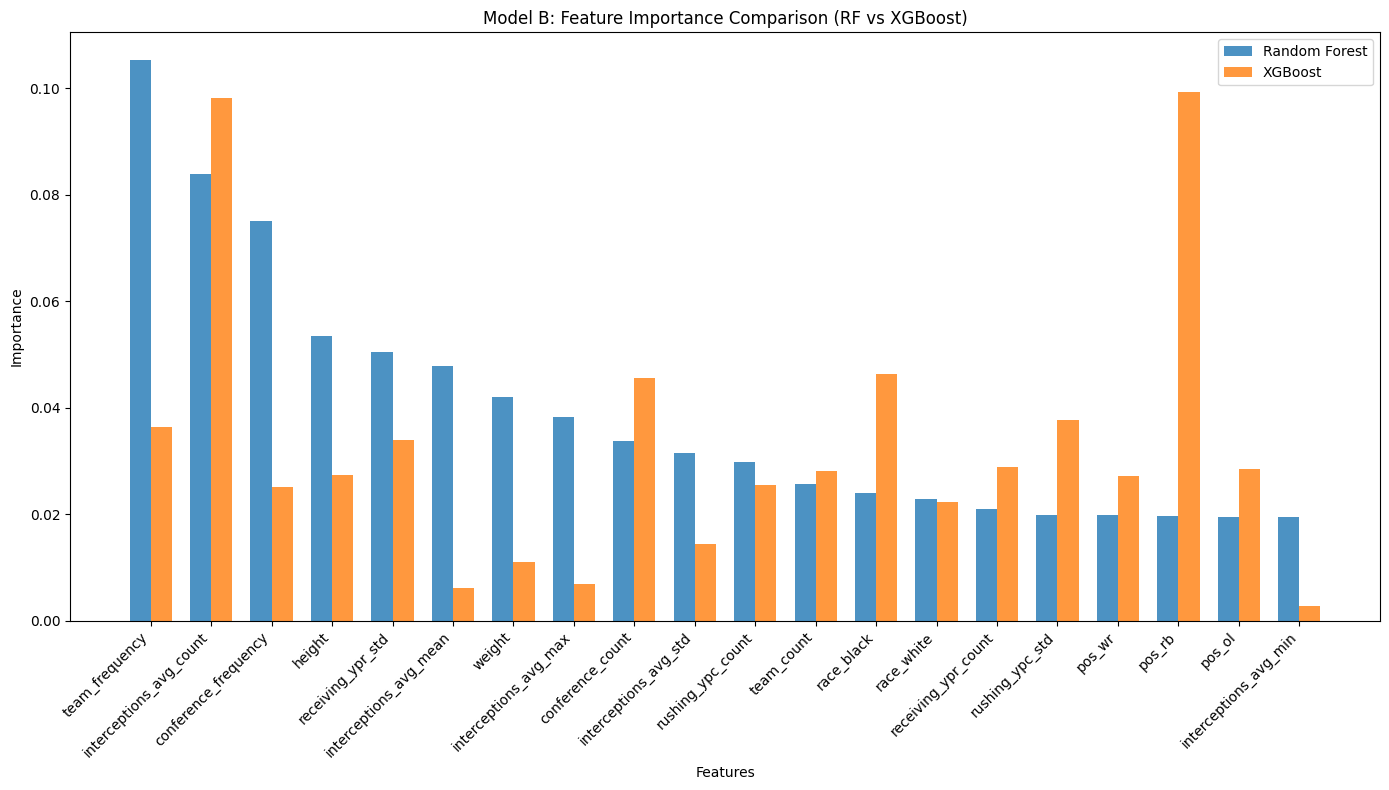


Features where XGBoost and RF disagree most:
XGBoost values higher:
            feature  importance_rf  importance_xgb      diff
17           pos_rb       0.019684        0.099328  0.079644
30           pos_qb       0.007020        0.029555  0.022535
12       race_black       0.024005        0.046383  0.022378
31           pos_te       0.005869        0.025828  0.019959
15  rushing_ypc_std       0.019826        0.037765  0.017939

Random Forest values higher:
                  feature  importance_rf  importance_xgb      diff
0          team_frequency       0.105284        0.036418 -0.068866
2    conference_frequency       0.075179        0.025106 -0.050073
5  interceptions_avg_mean       0.047845        0.006176 -0.041669
7   interceptions_avg_max       0.038285        0.006819 -0.031466
6                  weight       0.042011        0.010958 -0.031054


In [ ]:
# Cell 24: Compare feature importance between RF and XGBoost

importance_comparison = feature_importance.merge(
    xgb_feature_importance, 
    on='feature', 
    suffixes=('_rf', '_xgb')
)

# correlation between feature importances
importance_corr = importance_comparison[['importance_rf', 'importance_xgb']].corr().iloc[0,1]
print(f"Feature importance correlation between RF and XGBoost: {importance_corr:.3f}")

# comparison of top features
plt.figure(figsize=(14, 8))
top_20_comparison = importance_comparison.head(20)

x = range(len(top_20_comparison))
width = 0.35

plt.bar([i - width/2 for i in x], top_20_comparison['importance_rf'], 
        width, label='Random Forest', alpha=0.8)
plt.bar([i + width/2 for i in x], top_20_comparison['importance_xgb'], 
        width, label='XGBoost', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Model B: Feature Importance Comparison (RF vs XGBoost)')
plt.xticks(x, top_20_comparison['feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# biggest differences in feature importance
importance_comparison['diff'] = importance_comparison['importance_xgb'] - importance_comparison['importance_rf']
print("\nFeatures where XGBoost and RF disagree most:")
print("XGBoost values higher:")
print(importance_comparison.nlargest(5, 'diff')[['feature', 'importance_rf', 'importance_xgb', 'diff']])
print("\nRandom Forest values higher:")
print(importance_comparison.nsmallest(5, 'diff')[['feature', 'importance_rf', 'importance_xgb', 'diff']])

In [ ]:
# Cell 25: Final summary 

print(f"Dataset Overview:")
print(f"• Total players: {X_clean.shape[0]:,}")
print(f"• Features: {X_clean.shape[1]}")
print(f"• Drafted players: {y.sum():,} ({y.mean():.1%})")
print(f"• Class imbalance ratio: {(y==0).sum()//y.sum()}:1")

print(f"\nModel Performance Comparison:")
print(f"{'Metric':<25} {'Random Forest':<15} {'XGBoost':<15} {'Winner'}")
print(f"{'-'*65}")
print(f"{'ROC AUC':<25} {rf_auc:<15.4f} {xgb_auc:<15.4f} {'XGBoost' if xgb_auc > rf_auc else 'RF'}")
print(f"{'Drafted Recall':<25} {rf_recall_drafted:<15.1%} {xgb_recall_drafted:<15.1%} {'XGBoost' if xgb_recall_drafted > rf_recall_drafted else 'RF'}")

print(f"\nBIAS ANALYSIS RESULTS:")
print(f"{'Algorithm':<15} {'Bias Features %':<15} {'Risk Level'}")
print(f"{'-'*45}")
rf_bias_pct = ((feature_types['Race_Proxy'] + feature_types['Demographic_Risk'] + feature_types['Geographic_Risk']) / sum(feature_types.values())) * 100
xgb_bias_pct = ((xgb_feature_types['Race_Proxy'] + xgb_feature_types['Demographic_Risk'] + xgb_feature_types['Geographic_Risk']) / sum(xgb_feature_types.values())) * 100
print(f"{'Random Forest':<15} {rf_bias_pct:<15.1f} {'HIGH' if rf_bias_pct > 10 else 'MODERATE' if rf_bias_pct > 5 else 'LOW'}")
print(f"{'XGBoost':<15} {xgb_bias_pct:<15.1f} {'HIGH' if xgb_bias_pct > 10 else 'MODERATE' if xgb_bias_pct > 5 else 'LOW'}")

print(f"\nMost Problematic Features (both models):")
rf_biased_features = set(feature_importance[
    (feature_importance['feature'].str.startswith('race_')) |
    (feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate', 'home_state_frequency'])) |
    (feature_importance['feature'].str.startswith('density_'))
].head(10)['feature'])

xgb_biased_features = set(xgb_feature_importance[
    (xgb_feature_importance['feature'].str.startswith('race_')) |
    (xgb_feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate', 'home_state_frequency'])) |
    (xgb_feature_importance['feature'].str.startswith('density_'))
].head(10)['feature'])

common_biased_features = rf_biased_features & xgb_biased_features
for i, feat in enumerate(sorted(list(common_biased_features)[:5]), 1):
    print(f"{i}. {feat}")

print(f"\nTop Legitimate Performance Drivers (both models agree):")
rf_performance_features = set(feature_importance[
    ~feature_importance['feature'].str.startswith('pos_') &
    ~feature_importance['feature'].isin(['height', 'weight']) &
    ~feature_importance['feature'].str.contains('team|conference|race_|density_|home_state', case=False) &
    ~feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate'])
].head(10)['feature'])

xgb_performance_features = set(xgb_feature_importance[
    ~xgb_feature_importance['feature'].str.startswith('pos_') &
    ~xgb_feature_importance['feature'].isin(['height', 'weight']) &
    ~xgb_feature_importance['feature'].str.contains('team|conference|race_|density_|home_state', case=False) &
    ~xgb_feature_importance['feature'].isin(['median_income', 'poverty_rate', 'education_rate'])
].head(10)['feature'])

common_performance_features = rf_performance_features & xgb_performance_features
for i, feat in enumerate(sorted(list(common_performance_features)[:5]), 1):
    print(f"{i}. {feat}")
    

FINAL MODEL D SUMMARY: ALL FEATURES INCLUDING POTENTIALLY DISCRIMINATORY SIGNALS
⚠️  WARNING: This model includes discriminatory features for bias research only!
Dataset Overview:
• Total players: 42,021
• Features: 81 (efficiency + physical + contextual + DEMOGRAPHIC RISK)
  - Efficiency stats: 45 features
  - Position/Physical: 28 features
  - Team/Conference: 4 features
  - Demographic risk: 8 features ⚠️
  - Race proxy: 7 features ⚠️
• Drafted players: 1,444 (3.4%)
• Class imbalance ratio: 28:1

Model Performance Comparison:
Metric                    Random Forest   XGBoost         Winner
-----------------------------------------------------------------
ROC AUC                   0.8646          0.8917          XGBoost
Drafted Recall            36.0%           8.7%            RF

⚠️  BIAS ANALYSIS RESULTS:
Algorithm       Bias Features % Risk Level
---------------------------------------------
Random Forest   6.7             MODERATE
XGBoost         10.8            HIGH

Most Proble

# save results

In [ ]:

MODEL_SET_NAME = "Model_D"   # change per notebook

results_df = pd.DataFrame({
    "athlete_id": final_dataset.loc[X_test.index, "athlete_id"].values,
    "true_label": y_test.values,

    # Random Forest
    "rf_pred": y_pred,
    "rf_pred_proba": y_pred_proba[:, 1],

    # XGBoost
    "xgb_pred": y_pred_xgb,
    "xgb_pred_proba": y_pred_proba_xgb[:, 1],
})

results_df["model_set"] = MODEL_SET_NAME

os.makedirs("model_results", exist_ok=True)

output_path = f"model_results/{MODEL_SET_NAME}_results.csv"
results_df.to_csv(output_path, index=False)

print(f"saved to: {output_path}")

✅ Results saved to: model_results/Model_D_results.csv
Shape: (8405, 7)
